In [23]:
#Quantum aproximate optimization algorithm
import numpy as np
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
import networkx as nx
from qiskit.quantum_info import SparsePauliOp
from scipy.optimize import minimize
from qiskit.circuit.library import QAOAAnsatz
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

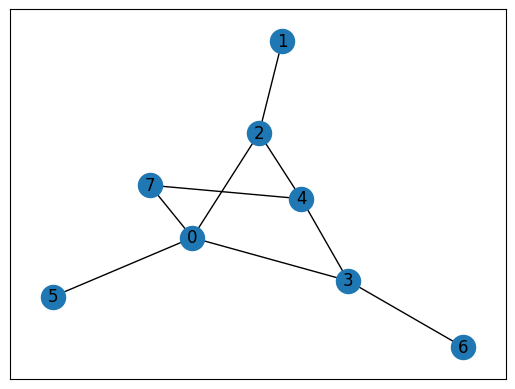

In [24]:
# G = nx.Graph()
# G.add_edges_from([[0,1],[0,3],[0,5],[0,7],[5,7],[1,2],[2,4],[3,4],[3,6]])
# nx.draw_networkx(G)

G = nx.Graph()
G.add_edges_from([[0,2],[0,3],[0,5],[0,7],[4,7],[1,2],[2,4],[3,4],[3,6]])
nx.draw_networkx(G)

In [25]:
# operator = SparsePauliOp.from_list(
#     [("IIIIIIZZ", 0.5), 
#      ("IIIIZIIZ", 0.5), 
#      ("IIZIIIIZ", 0.5), 
#      ("ZIIIIIIZ", 0.5), 
#      ("ZIZIIIII", 0.5), 
#      ("IIIIIZZI", 0.5), 
#      ("IIIZIZII", 0.5), 
#      ("IIIZZIII", 0.5), 
#      ("IZIIZIII", 0.5),]
# )

operator = SparsePauliOp.from_list(
    [("IIIIIZIZ", 0.5), 
     ("IIIIZIIZ", 0.5), 
     ("IIZIIIIZ", 0.5), 
     ("ZIIIIIIZ", 0.5), 
     ("ZIIZIIII", 0.5), 
     ("IIIIIZZI", 0.5), 
     ("IIIZIZII", 0.5), 
     ("IIIZZIII", 0.5), 
     ("IZIIZIII", 0.5),]
)

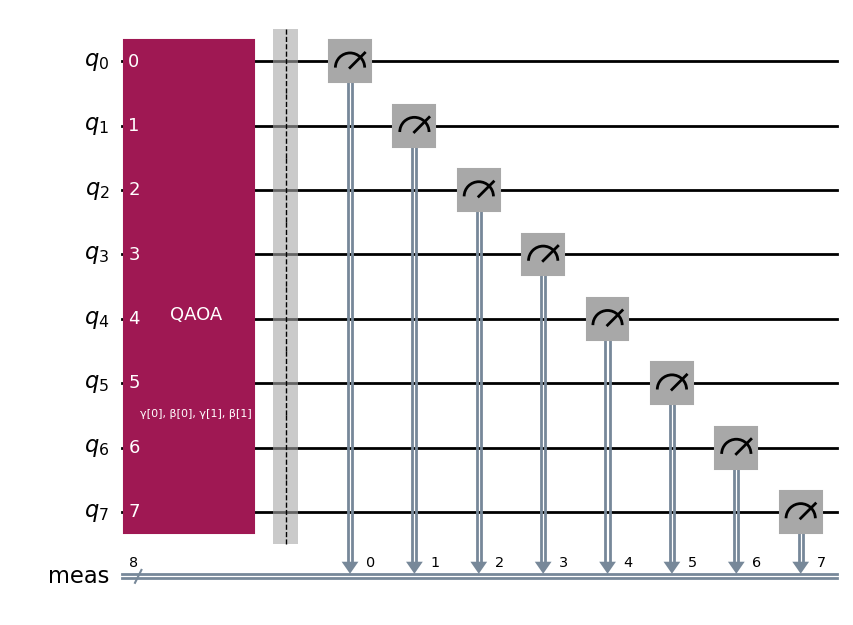

In [26]:
circuit = QAOAAnsatz(cost_operator=operator, reps=2)
circuit.measure_all()

circuit.draw('mpl')

In [ ]:
costs = []

In [27]:
my_backend = GenericBackendV2(num_qubits=8)

In [28]:
def cost_func(params, ansatz, hamiltonian, estimator):
    mapped_hamiltonian = hamiltonian.apply_layout(ansatz.layout)
    pub = (ansatz, mapped_hamiltonian, params)
    job = estimator.run([pub])
    results = job.result()[0]
    cost = results.data.evs
    costs.append(cost)
    print(len(costs), cost)
    return cost

In [29]:
num_params = circuit.num_parameters
x0 = np.pi * np.random.random(num_params)

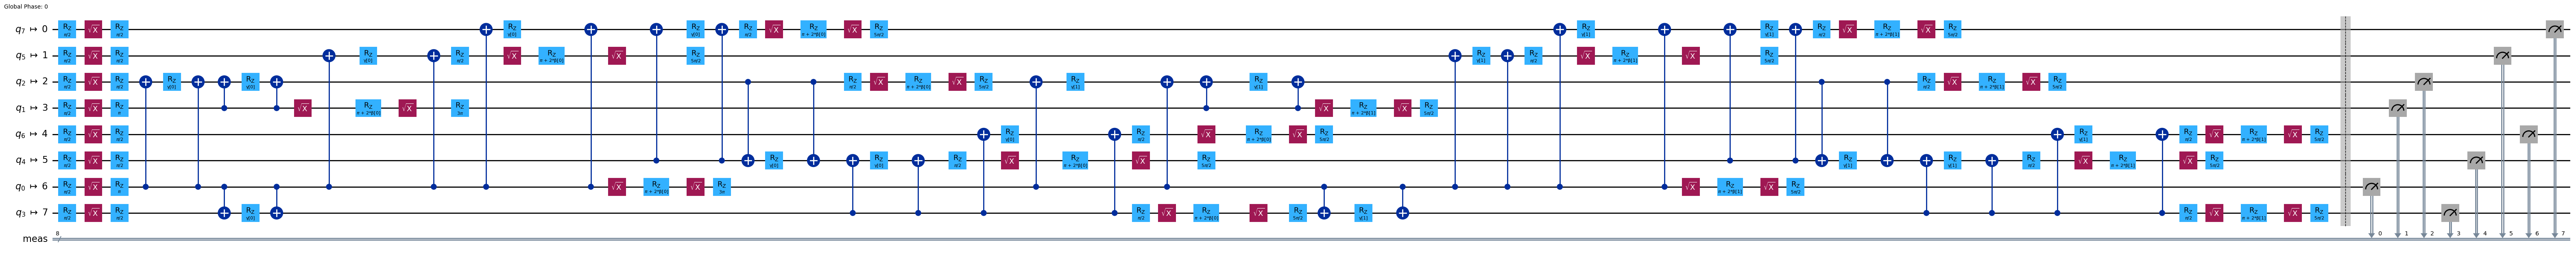

In [30]:
pm = generate_preset_pass_manager(optimization_level=3,
                                    backend=my_backend)

transpiled_circuit = pm.run(circuit)
transpiled_circuit.draw('mpl', fold=False, idle_wires=False)

In [31]:
costs = []
import warnings

with Session(backend=my_backend) as session:
    
    warnings.filterwarnings(
    "ignore",
    message=".*have no effect in local testing mode.*"
)
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 10000

    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"
    
    result = minimize(
        cost_func,
        x0,
        args=(transpiled_circuit, operator, estimator),
        method="COBYLA",
        tol=1e-2,
    )
    print(result)



1 1.0327000000000002
2 -0.11359999999999998
3 -1.2822
4 -0.1016
5 -0.5220999999999999
6 1.2373999999999998
7 -0.2158
8 -1.2316
9 -1.3412
10 -0.5121
11 -1.3709000000000002
12 -1.6619000000000002
13 -1.7424000000000002
14 -1.5688000000000002
15 -1.5387
16 -1.9047
17 -1.9983
18 -1.8659
19 -1.8971
20 -2.0161
21 -1.9973
22 -1.7756
23 -2.1006
24 -2.0597
25 -2.1016
26 -2.1979
27 -2.2719
28 -2.3571
29 -2.3526
30 -2.3325
31 -2.3583
32 -2.3225999999999996
33 -2.4182
34 -2.302
35 -2.4919000000000002
36 -2.5458000000000003
37 -2.5549999999999997
38 -2.5839000000000003
39 -2.4766
40 -2.5845000000000002
41 -2.6084
42 -2.5516
43 -2.6102000000000003
44 -2.6015
45 -2.606
46 -2.5951999999999997
47 -2.6113
48 -2.6033999999999997
49 -2.6321999999999997
50 -2.6005999999999996
51 -2.6029
52 -2.6123999999999996
53 -2.6139
54 -2.6082000000000005
55 -2.6233
 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -2.6233
       x: [ 2.606e+00  1.238e+00  6.314e-01  8.980e-01]
    nf

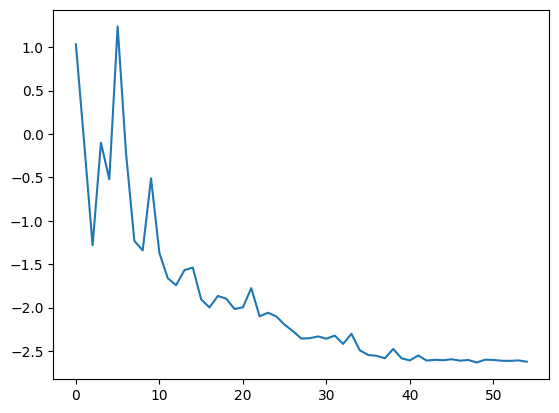

In [32]:
import matplotlib.pyplot as plt
plt.plot(costs)

In [33]:
optimized_circuit = transpiled_circuit.assign_parameters(result.x)

In [34]:
shots = 10000

sampler = Sampler(mode=my_backend)
sampler.options.default_shots = shots

pub= (optimized_circuit, )
job = sampler.run([pub], shots=shots)
counts_int = job.result()[0].data.meas.get_int_counts()
counts = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val / shots for key, val in counts_int.items()}

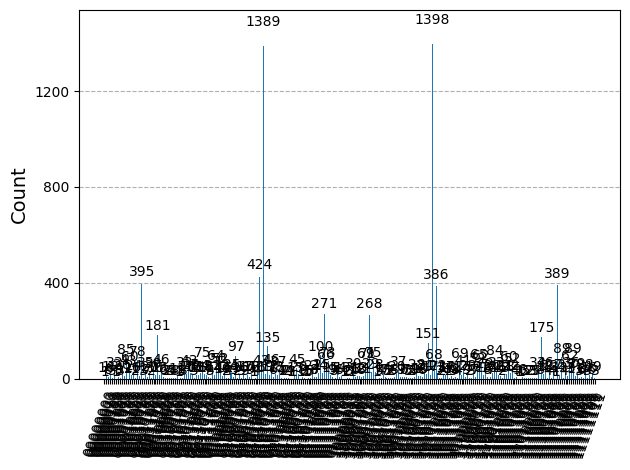

In [35]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

In [36]:
# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]
 
keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, G.number_of_nodes())
most_likely_bitstring.reverse()
 
print("Result bitstring:", most_likely_bitstring)

Result bitstring: [0, 0, 1, 1, 0, 1, 0, 1]


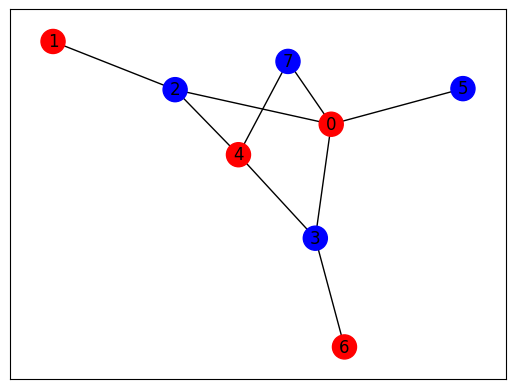

In [37]:
colors = ['r' if most_likely_bitstring[node] == 0 else 'b' for node in G]
nx.draw_networkx(G,node_color = colors)

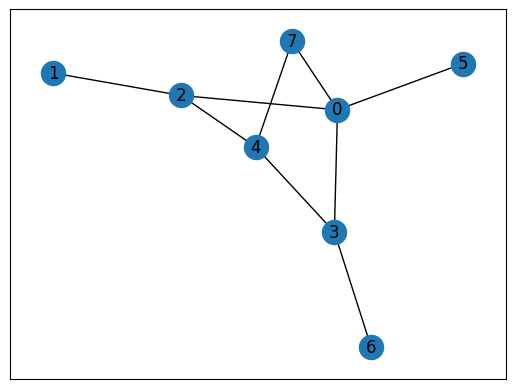

In [38]:
G = nx.Graph()
G.add_edges_from([[0,2],[0,3],[0,5],[0,7],[4,7],[1,2],[2,4],[3,4],[3,6]])
nx.draw_networkx(G)

Best cut: 9
Best coloring: {0: 0, 2: 1, 3: 1, 5: 1, 7: 1, 4: 0, 1: 0, 6: 0}


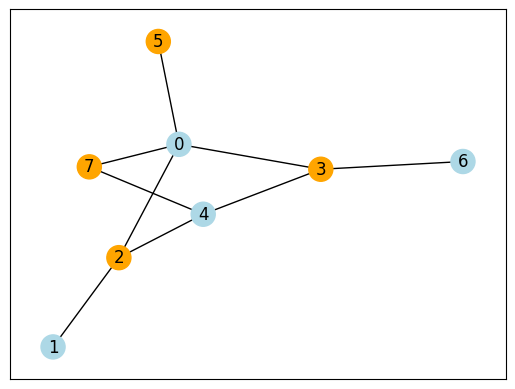

In [39]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import product

G = nx.Graph()
G.add_edges_from([[0,2],[0,3],[0,5],[0,7],[4,7],[1,2],[2,4],[3,4],[3,6]])

nodes = list(G.nodes())

best_cut = -1
best_coloring = None

for coloring in product([0, 1], repeat=len(nodes)):
    color_dict = dict(zip(nodes, coloring))
    cut_value = 0

    for u, v in G.edges():
        if color_dict[u] != color_dict[v]:
            cut_value += 1

    if cut_value > best_cut:
        best_cut = cut_value
        best_coloring = color_dict

print("Best cut:", best_cut)
print("Best coloring:", best_coloring)

colors = ["lightblue" if best_coloring[node] == 0 else "orange" for node in G.nodes()]

nx.draw_networkx(G, node_color=colors, with_labels=True)
plt.show()

In [40]:
operator = SparsePauliOp.from_list(
    [("IIIIIZIZ", 0.5), 
     ("IIIIZIIZ", 0.5), 
     ("IIZIIIIZ", 0.5), 
     ("ZIIIIIIZ", 0.5), 
     ("ZIIZIIII", 0.5), 
     ("IIIIIZZI", 0.5), 
     ("IIIZIZII", 0.5), 
     ("IIIZZIII", 0.5), 
     ("IZIIZIII", 0.5),]
)

## Exercise
* Define your own 8-node graph and use 'frute-force' method to find MAX-CUT for it (checking all color possibilities and choosing the one with max cut).
* Use Qiskit to run QAOA algorithm to solve MAX-CUT problem for the same graph, run it on simulator and compare result with brute-force.
* Run the QAOA algorithm on real backend and compare results.

This link may be helpful: https://quantum.cloud.ibm.com/docs/en/tutorials/quantum-approximate-optimization-algorithm